In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

print("Setup Successful")

Setup Successful


In [69]:
df = pd.read_csv("../data/raw/user_data_cleaned.csv")

df.head()










,Timestamp,Age,Gender,AcademicLevel,FieldOfStudy,PhoneUsage,AppCategory,UsagePeriod,CheckWhileStudying,StudyHours,SleepDuration,Scale
0,2026-05-07 18:36:00,23-25,Male,UG,Computer Science,2-4 hours,Social Media,Late Night,Very Often,3-4 hours,7-8 hours,4
1,2026-05-07 18:37:00,26-28,Female,PG,Computer Science,6-8 hours,Social Media,Late Night,Sometimes,Less than 1 hour,7-8 hours,5
2,2026-05-07 18:37:00,20-22,Prefer not to say,UG,Computer Science,4-6 hours,Messaging,Afternoon,Often,1-2 hours,7-8 hours,4
3,2026-05-07 18:39:00,23-25,Female,UG,Computer Science,6-8 hours,Social Media,Evening,Often,5-6 hours,5-6 hours,5
4,2026-05-07 18:39:00,23-25,Female,PG,Others,6-8 hours,Social Media,Late Night,Often,Less than 1 hour,More than 8 hours,5


In [70]:
df.index=df.index+1
df.head()

,Timestamp,Age,Gender,AcademicLevel,FieldOfStudy,PhoneUsage,AppCategory,UsagePeriod,CheckWhileStudying,StudyHours,SleepDuration,Scale
1,2026-05-07 18:36:00,23-25,Male,UG,Computer Science,2-4 hours,Social Media,Late Night,Very Often,3-4 hours,7-8 hours,4
2,2026-05-07 18:37:00,26-28,Female,PG,Computer Science,6-8 hours,Social Media,Late Night,Sometimes,Less than 1 hour,7-8 hours,5
3,2026-05-07 18:37:00,20-22,Prefer not to say,UG,Computer Science,4-6 hours,Messaging,Afternoon,Often,1-2 hours,7-8 hours,4
4,2026-05-07 18:39:00,23-25,Female,UG,Computer Science,6-8 hours,Social Media,Evening,Often,5-6 hours,5-6 hours,5
5,2026-05-07 18:39:00,23-25,Female,PG,Others,6-8 hours,Social Media,Late Night,Often,Less than 1 hour,More than 8 hours,5


In [71]:
df.shape

(58, 12)

In [72]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 1 to 58
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Timestamp           58 non-null     str  
 1   Age                 58 non-null     str  
 2   Gender              58 non-null     str  
 3   AcademicLevel       58 non-null     str  
 4   FieldOfStudy        58 non-null     str  
 5   PhoneUsage          58 non-null     str  
 6   AppCategory         58 non-null     str  
 7   UsagePeriod         58 non-null     str  
 8   CheckWhileStudying  58 non-null     str  
 9   StudyHours          58 non-null     str  
 10  SleepDuration       58 non-null     str  
 11  Scale               58 non-null     int64
dtypes: int64(1), str(11)
memory usage: 5.6 KB


In [73]:
df.describe(include="all")

,Timestamp,Age,Gender,AcademicLevel,FieldOfStudy,PhoneUsage,AppCategory,UsagePeriod,CheckWhileStudying,StudyHours,SleepDuration,Scale
count,58,58,58,58,58,58,58,58,58,58,58,58.000000
unique,54,3,4,3,7,5,7,4,5,5,5,NaN
top,2026-05-07 18:39:00,23-25,Male,UG,Computer Science,4-6 hours,Social Media,Late Night,Sometimes,3-4 hours,7-8 hours,NaN
freq,3,29,29,43,26,24,41,26,18,23,22,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.051724
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.234339
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


In [74]:
df.isnull().sum()

Timestamp             0
Age                   0
Gender                0
AcademicLevel         0
FieldOfStudy          0
PhoneUsage            0
AppCategory           0
UsagePeriod           0
CheckWhileStudying    0
StudyHours            0
SleepDuration         0
Scale                 0
dtype: int64

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.nunique()

Timestamp             54
Age                    3
Gender                 4
AcademicLevel          3
FieldOfStudy           7
PhoneUsage             5
AppCategory            7
UsagePeriod            4
CheckWhileStudying     5
StudyHours             5
SleepDuration          5
Scale                  5
dtype: int64

In [77]:
df['AppCategory'].unique()

<StringArray>
[   'Social Media',       'Messaging',       'Education',           'Other',
    'Productivity', 'Video Streaming',          'Gaming']
Length: 7, dtype: str

In [78]:
df["StudyHours"].unique()

<StringArray>
['3-4 hours', 'Less than 1 hour', '1-2 hours', '5-6 hours',
 'More than 6 hours']
Length: 5, dtype: str

In [79]:
df["SleepDuration"].unique()

<StringArray>
['7-8 hours', '5-6 hours', 'More than 8 hours', '6-7 hours',
 'Less than 5 hours']
Length: 5, dtype: str

In [80]:
df["CheckWhileStudying"].unique()

<StringArray>
['Very Often', 'Sometimes', 'Often', 'Occasionally', 'Never']
Length: 5, dtype: str

In [81]:
screen_time_map = {
    "Less than 2 hours": 1,
    "2–4 hours": 3,
    "4–6 hours": 5,
    "6–8 hours": 7,
    "More than 8 hours": 9,
}

df["ScreenTimeHours"] = df["PhoneUsage"].map(screen_time_map)

In [82]:
study_map = {
    "Less than 1 hour": 0.5,
    "1–2 hours": 1.5,
    "3–4 hours": 3.5,
    "5–6 hours": 5.5,
    "More than 6 hours": 7
}

df["StudyHoursNumeric"] = df["StudyHours"].map(study_map)

In [83]:
check_map = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Very Often": 5}

df["PhoneCheckScore"] = df["CheckWhileStudying"].map(check_map)

In [84]:
SleepTime_map={
    "Less than 5 hours":4,
    "5-6 hours":5.5,
    "6-7 hours":6.5,
    "7-8 hours":7.5,
    "More than 8 hours":9
    }
df["SleepingHours"] = df["SleepDuration"].map( SleepTime_map)

In [85]:
df[["SleepDuration", "SleepingHours"]].head()

,SleepDuration,SleepingHours
1,7-8 hours,7.5
2,7-8 hours,7.5
3,7-8 hours,7.5
4,5-6 hours,5.5
5,More than 8 hours,9.0


In [86]:
df["SleepingHours"].isna().sum()

np.int64(0)

In [87]:
df["ScreenTimeRate"]=np.where(
    df["ScreenTimeHours"]>=6,
    "High",
    "Low/Moderate"
)

In [88]:
df["SleepQuality"]=np.where(
    df["SleepingHours"]>=7,
    "Adequate Sleep",
    "Inadequate Sleep"
)

In [89]:
df[["SleepDuration", "SleepingHours", "SleepQuality"]].head(10)

,SleepDuration,SleepingHours,SleepQuality
1,7-8 hours,7.5,Adequate Sleep
2,7-8 hours,7.5,Adequate Sleep
3,7-8 hours,7.5,Adequate Sleep
4,5-6 hours,5.5,Inadequate Sleep
5,More than 8 hours,9.0,Adequate Sleep
6,6-7 hours,6.5,Inadequate Sleep
7,7-8 hours,7.5,Adequate Sleep
8,6-7 hours,6.5,Inadequate Sleep
9,7-8 hours,7.5,Adequate Sleep
10,6-7 hours,6.5,Inadequate Sleep


In [90]:
df["SleepQuality"].value_counts()

SleepQuality
Inadequate Sleep    30
Adequate Sleep      28
Name: count, dtype: int64

In [91]:
df["HighDistraction"] = np.where(
    (df["ScreenTimeHours"] >= 6) & (df["PhoneCheckScore"] >= 4), "Yes", "No"
)

In [92]:
df.head()

,Timestamp,Age,Gender,AcademicLevel,FieldOfStudy,PhoneUsage,AppCategory,UsagePeriod,CheckWhileStudying,StudyHours,SleepDuration,Scale,ScreenTimeHours,StudyHoursNumeric,PhoneCheckScore,SleepingHours,ScreenTimeRate,SleepQuality,HighDistraction
1,2026-05-07 18:36:00,23-25,Male,UG,Computer Science,2-4 hours,Social Media,Late Night,Very Often,3-4 hours,7-8 hours,4,NaN,NaN,5.0,7.5,Low/Moderate,Adequate Sleep,No
2,2026-05-07 18:37:00,26-28,Female,PG,Computer Science,6-8 hours,Social Media,Late Night,Sometimes,Less than 1 hour,7-8 hours,5,NaN,0.5,3.0,7.5,Low/Moderate,Adequate Sleep,No
3,2026-05-07 18:37:00,20-22,Prefer not to say,UG,Computer Science,4-6 hours,Messaging,Afternoon,Often,1-2 hours,7-8 hours,4,NaN,NaN,4.0,7.5,Low/Moderate,Adequate Sleep,No
4,2026-05-07 18:39:00,23-25,Female,UG,Computer Science,6-8 hours,Social Media,Evening,Often,5-6 hours,5-6 hours,5,NaN,NaN,4.0,5.5,Low/Moderate,Inadequate Sleep,No
5,2026-05-07 18:39:00,23-25,Female,PG,Others,6-8 hours,Social Media,Late Night,Often,Less than 1 hour,More than 8 hours,5,NaN,0.5,4.0,9.0,Low/Moderate,Adequate Sleep,No


In [93]:
print(df["PhoneUsage"].unique())

<StringArray>
['2-4 hours', '6-8 hours', '4-6 hours', 'More than 8 hours',
 'Less than 2 hours']
Length: 5, dtype: str


In [94]:
df[df["ScreenTimeHours"].isna()][["PhoneUsage"]]

,PhoneUsage
1,2-4 hours
2,6-8 hours
3,4-6 hours
4,6-8 hours
5,6-8 hours
6,4-6 hours
9,4-6 hours
10,6-8 hours
11,6-8 hours
12,4-6 hours


In [95]:
ScreenTime_map = {
    "Less than 2 hours": 1,
    "2-4 hours": 3,
    "4-6 hours": 5,
    "6-8 hours": 7,
    "More than 8 hours": 8.5
}

df["ScreenTimeHours"] = df["PhoneUsage"].map(ScreenTime_map)

In [96]:
df["ScreenTimeHours"].head()

1    3.0
2    7.0
3    5.0
4    7.0
5    7.0
Name: ScreenTimeHours, dtype: float64

In [97]:
df.head()

,Timestamp,Age,Gender,AcademicLevel,FieldOfStudy,PhoneUsage,AppCategory,UsagePeriod,CheckWhileStudying,StudyHours,SleepDuration,Scale,ScreenTimeHours,StudyHoursNumeric,PhoneCheckScore,SleepingHours,ScreenTimeRate,SleepQuality,HighDistraction
1,2026-05-07 18:36:00,23-25,Male,UG,Computer Science,2-4 hours,Social Media,Late Night,Very Often,3-4 hours,7-8 hours,4,3.0,NaN,5.0,7.5,Low/Moderate,Adequate Sleep,No
2,2026-05-07 18:37:00,26-28,Female,PG,Computer Science,6-8 hours,Social Media,Late Night,Sometimes,Less than 1 hour,7-8 hours,5,7.0,0.5,3.0,7.5,Low/Moderate,Adequate Sleep,No
3,2026-05-07 18:37:00,20-22,Prefer not to say,UG,Computer Science,4-6 hours,Messaging,Afternoon,Often,1-2 hours,7-8 hours,4,5.0,NaN,4.0,7.5,Low/Moderate,Adequate Sleep,No
4,2026-05-07 18:39:00,23-25,Female,UG,Computer Science,6-8 hours,Social Media,Evening,Often,5-6 hours,5-6 hours,5,7.0,NaN,4.0,5.5,Low/Moderate,Inadequate Sleep,No
5,2026-05-07 18:39:00,23-25,Female,PG,Others,6-8 hours,Social Media,Late Night,Often,Less than 1 hour,More than 8 hours,5,7.0,0.5,4.0,9.0,Low/Moderate,Adequate Sleep,No


In [98]:
df[df["StudyHoursNumeric"].isna()][["StudyHours"]]

,StudyHours
1,3-4 hours
3,1-2 hours
4,5-6 hours
6,3-4 hours
8,1-2 hours
9,3-4 hours
10,1-2 hours
11,3-4 hours
12,1-2 hours
15,3-4 hours


In [99]:
study_map = {
    "Less than 1 hour": 0.5,
    "1-2 hours": 1.5,
    "3-4 hours": 3.5,
    "5-6 hours": 5.5,
    "More than 6 hours": 7,
}

df["StudyHoursNumeric"] = df["StudyHours"].map(study_map)

In [100]:
df["StudyHoursNumeric"].head(10)

1     3.5
2     0.5
3     1.5
4     5.5
5     0.5
6     3.5
7     0.5
8     1.5
9     3.5
10    1.5
Name: StudyHoursNumeric, dtype: float64

In [101]:
df.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'AcademicLevel',
 'FieldOfStudy',
 'PhoneUsage',
 'AppCategory',
 'UsagePeriod',
 'CheckWhileStudying',
 'StudyHours',
 'SleepDuration',
 'Scale',
 'ScreenTimeHours',
 'StudyHoursNumeric',
 'PhoneCheckScore',
 'SleepingHours',
 'ScreenTimeRate',
 'SleepQuality',
 'HighDistraction']

In [ ]:
df.rename(
    columns={
        "Timestamp": "timestamp",
        "Age": "age",
        "Gender": "gender",
        "AcademicLevel": "academic_level",
        "FieldOfStudy": "field_of_study",
        "PhoneUsage": "phone_usage",
        "AppCategory": "app_category",
        "UsagePeriod": "usage_period",
        "CheckWhileStudying": "check_while_studying",
        "StudyHours": "study_hours",
        "SleepDuration": "sleep_duration",
        "Scale": "procrastination_score",
        "ScreenTimeHours": "screen_time_hours",
        "StudyHoursNumeric": "study_hours_numeric",
        "SleepingHours": "sleeping_hours",
        "PhoneCheckScore": "phone_check_score",
        "SleepQuality": "sleep_quality",
        "HighDistraction": "high_distraction",
    },
    inplace=True,
)

VISUALIZATION


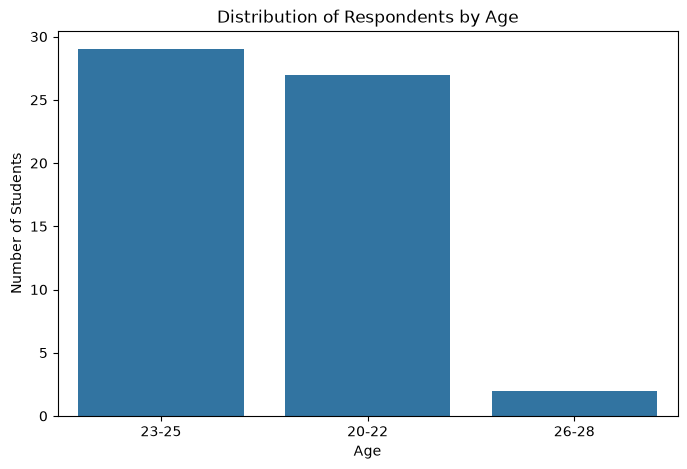

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="age", order=df["age"].value_counts().index)

plt.title("Distribution of Respondents by Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

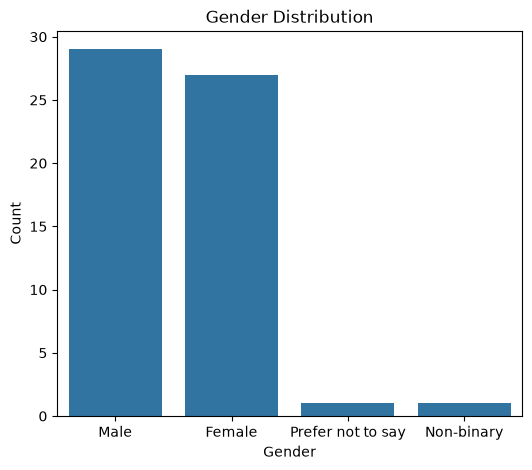

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

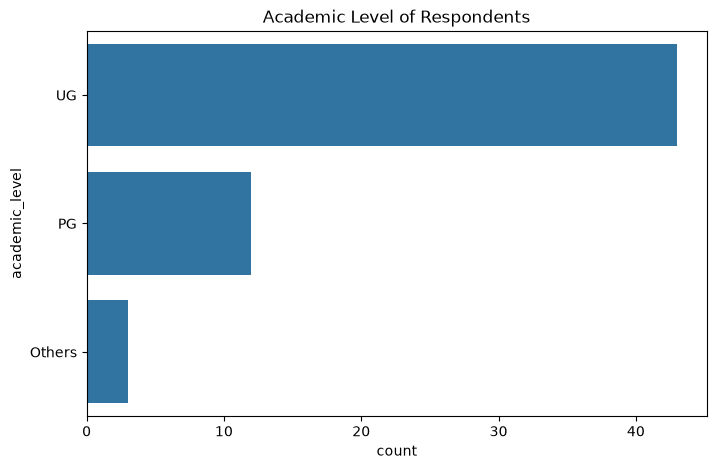

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df, y="academic_level", order=df["academic_level"].value_counts().index
)

plt.title("Academic Level of Respondents")

plt.show()

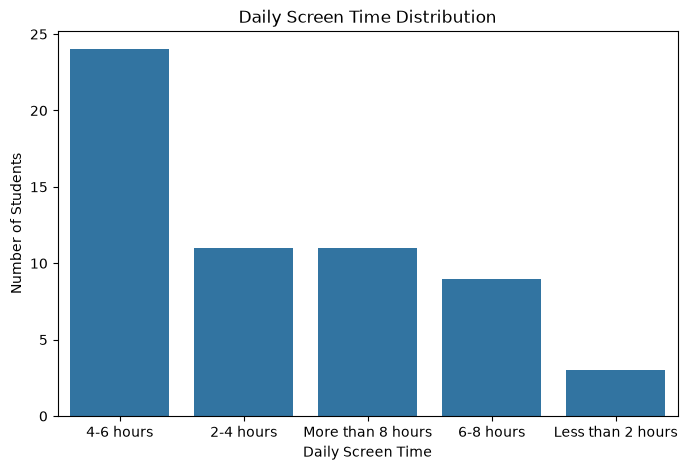

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="phone_usage", order=df["phone_usage"].value_counts().index)

plt.title("Daily Screen Time Distribution")
plt.xlabel("Daily Screen Time")
plt.ylabel("Number of Students")

plt.show()

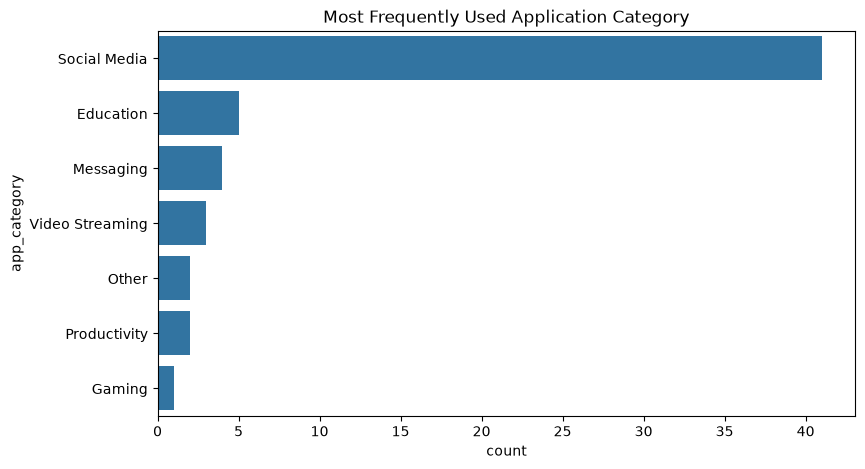

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, y="app_category", order=df["app_category"].value_counts().index)

plt.title("Most Frequently Used Application Category")

plt.show()

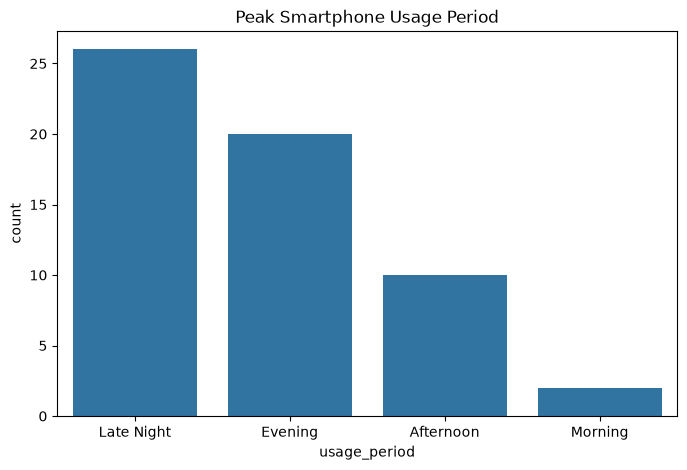

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="usage_period", order=df["usage_period"].value_counts().index)

plt.title("Peak Smartphone Usage Period")

plt.show()

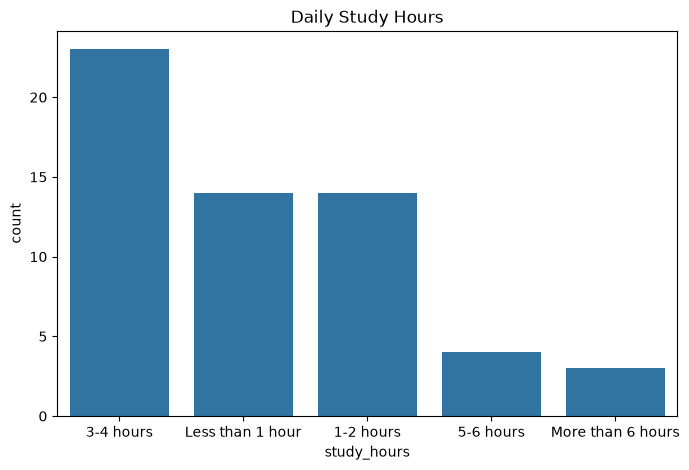

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="study_hours", order=df["study_hours"].value_counts().index)

plt.title("Daily Study Hours")

plt.show()

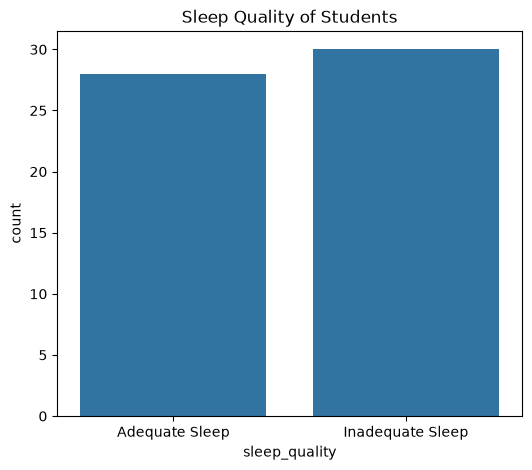

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="sleep_quality")

plt.title("Sleep Quality of Students")

plt.show()

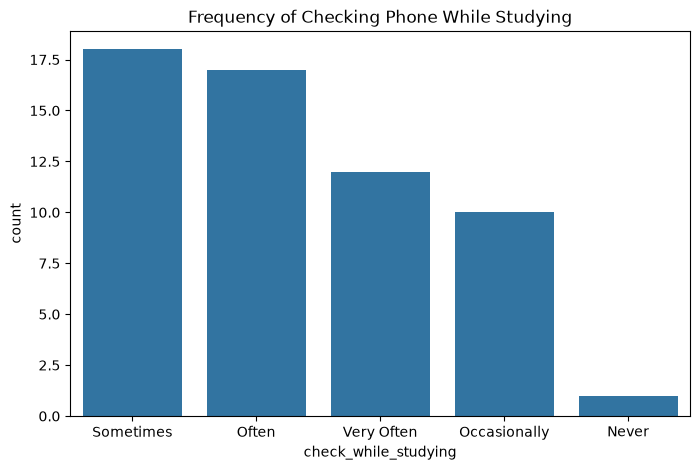

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="check_while_studying",
    order=df["check_while_studying"].value_counts().index,
)

plt.title("Frequency of Checking Phone While Studying")

plt.show()

In [104]:
print(df.columns)

Index(['Timestamp', 'Age', 'Gender', 'AcademicLevel', 'FieldOfStudy',
       'PhoneUsage', 'AppCategory', 'UsagePeriod', 'CheckWhileStudying',
       'StudyHours', 'SleepDuration', 'Scale', 'ScreenTimeHours',
       'StudyHoursNumeric', 'PhoneCheckScore', 'SleepingHours',
       'ScreenTimeRate', 'SleepQuality', 'HighDistraction'],
      dtype='str')


In [134]:
df.rename(
    columns={
        "Timestamp": "timestamp",
        "Age": "age",
        "Gender": "gender",
        "AcademicLevel": "academic_level",
        "FieldOfStudy": "field_of_study",
        "PhoneUsage": "phone_usage",
        "ScreenTimeRate":"screen_time_rate",
        "AppCategory": "app_category",
        "UsagePeriod": "usage_period",
        "CheckWhileStudying": "check_while_studying",
        "StudyHours": "study_hours",
        "SleepDuration": "sleep_duration",
        "Scale": "procrastination_score",
        "ScreenTimeHours": "screen_time_hours",
        "StudyHoursNumeric": "study_hours_numeric",
        "SleepingHours": "sleeping_hours",
        "PhoneCheckScore": "phone_check_score",
        "SleepQuality": "sleep_quality",
        "HighDistraction": "high_distraction",
    },
    inplace=True,
)

In [135]:
df.columns

Index(['age', 'gender', 'academic_level', 'field_of_study', 'phone_usage',
       'app_category', 'usage_period', 'check_while_studying', 'study_hours',
       'sleep_duration', 'procrastination_score', 'screen_time_hours',
       'study_hours_numeric', 'phone_check_score', 'sleeping_hours',
       'screen_time_hours', 'sleep_quality', 'high_distraction'],
      dtype='str')

In [138]:
df.head()

,age,gender,academic_level,field_of_study,phone_usage,app_category,usage_period,check_while_studying,study_hours,sleep_duration,procrastination_score,screen_time_hours,study_hours_numeric,phone_check_score,sleeping_hours,screen_time_rate,sleep_quality,high_distraction
1,23-25,Male,UG,Computer Science,2-4 hours,Social Media,Late Night,Very Often,3-4 hours,7-8 hours,4,3.0,3.5,5.0,7.5,Low/Moderate,Adequate Sleep,No
2,26-28,Female,PG,Computer Science,6-8 hours,Social Media,Late Night,Sometimes,Less than 1 hour,7-8 hours,5,7.0,0.5,3.0,7.5,Low/Moderate,Adequate Sleep,No
3,20-22,Prefer not to say,UG,Computer Science,4-6 hours,Messaging,Afternoon,Often,1-2 hours,7-8 hours,4,5.0,1.5,4.0,7.5,Low/Moderate,Adequate Sleep,No
4,23-25,Female,UG,Computer Science,6-8 hours,Social Media,Evening,Often,5-6 hours,5-6 hours,5,7.0,5.5,4.0,5.5,Low/Moderate,Inadequate Sleep,No
5,23-25,Female,PG,Others,6-8 hours,Social Media,Late Night,Often,Less than 1 hour,More than 8 hours,5,7.0,0.5,4.0,9.0,Low/Moderate,Adequate Sleep,No


In [137]:
df.columns.values[15] = "screen_time_rate"

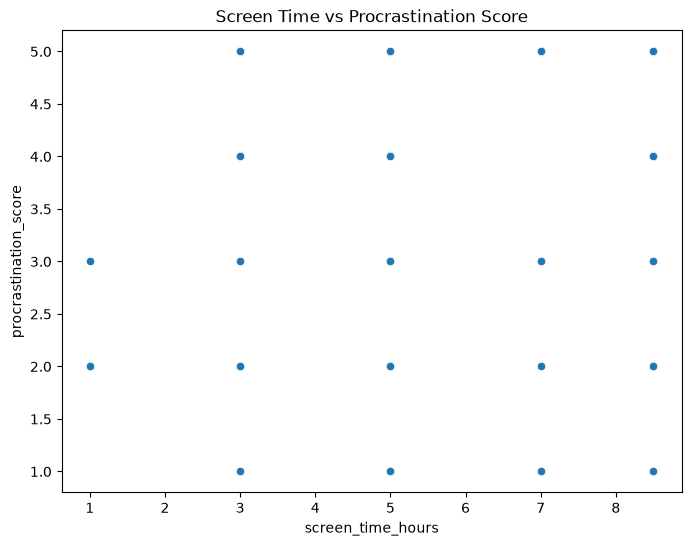

In [107]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="screen_time_hours", y="procrastination_score")

plt.title("Screen Time vs Procrastination Score")

plt.show()

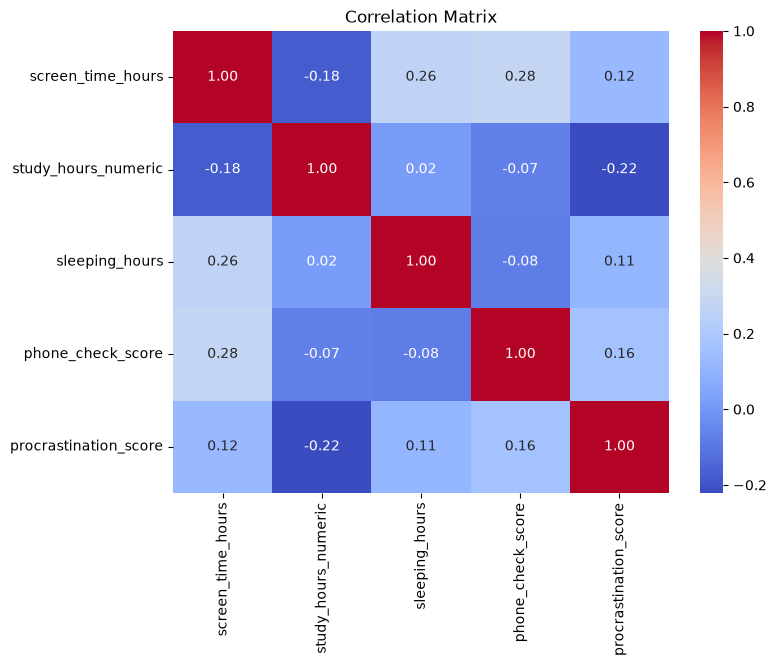

In [108]:
plt.figure(figsize=(8, 6))

corr = df[
    [
        "screen_time_hours",
        "study_hours_numeric",
        "sleeping_hours",
        "phone_check_score",
        "procrastination_score",
    ]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

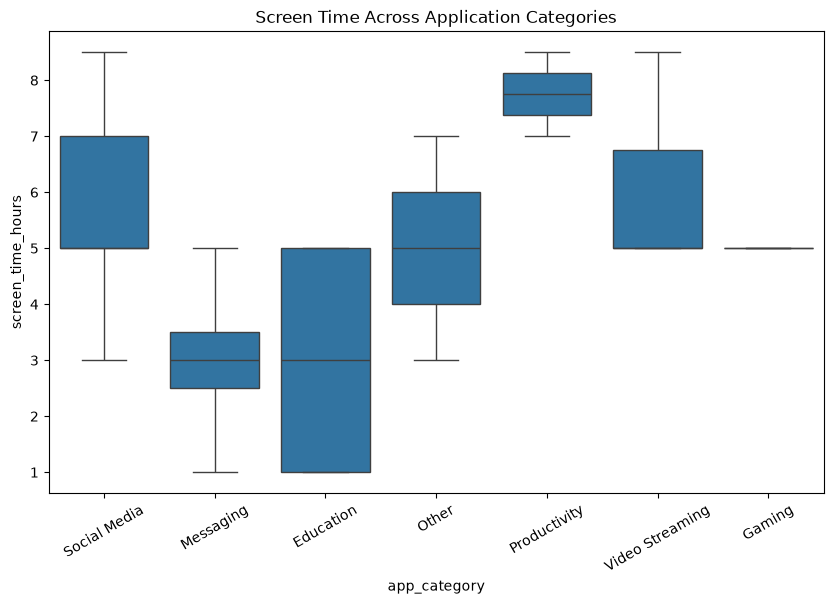

In [109]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="app_category", y="screen_time_hours")

plt.xticks(rotation=30)

plt.title("Screen Time Across Application Categories")

plt.show()

In [110]:
average_screen_time = df["screen_time_hours"].mean()

average_sleep = df["sleeping_hours"].mean()

average_study = df["study_hours_numeric"].mean()

average_procrastination = df["procrastination_score"].mean()

In [111]:
print(" Key Performance Indicators (KPIs) \n")

print(f"Average Screen Time      : {average_screen_time:.2f} hours")
print(f"Average Study Hours      : {average_study:.2f} hours")
print(f"Average Sleep Duration   : {average_sleep:.2f} hours")
print(f"Average Procrastination Score : {average_procrastination:.2f}")

 Key Performance Indicators (KPIs) 

Average Screen Time      : 5.39 hours
Average Study Hours      : 2.61 hours
Average Sleep Duration   : 6.96 hours
Average Procrastination Score : 3.05


In [ ]:
print(" Key Performance Indicators (KPIs) \n")

print(f"Average Screen Time      : {average_screen_time:.2f} hours")
print(f"Average Study Hours      : {average_study:.2f} hours")
print(f"Average Sleep Duration   : {average_sleep:.2f} hours")
print(f"Average Procrastination Score : {average_procrastination:.2f}")

 Key Performance Indicators (KPIs) 

Average Screen Time      : 5.39 hours
Average Study Hours      : 2.61 hours
Average Sleep Duration   : 6.96 hours
Average Procrastination Score : 3.05


## KPI Interpretation

The average daily screen time among respondents was 5.39, indicating moderate to high smartphone engagement.

Students studied an average of 2.61 per day while sleeping approximately 6.96 on average.

The average procrastination score 3.05  suggests that students experience a moderate level of procrastination, providing an opportunity for digital productivity interventions.

In [140]:
df[
    [
        "screen_time_hours",
        "study_hours_numeric",
        "sleeping_hours",
        "procrastination_score",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
screen_time_hours,58.0,5.387931,2.111047,1.0,5.0,5.0,7.0,8.5
study_hours_numeric,58.0,2.612069,1.821035,0.5,1.5,3.5,3.5,7.0
sleeping_hours,58.0,6.956897,1.039924,4.0,6.5,6.5,7.5,9.0
procrastination_score,58.0,3.051724,1.234339,1.0,2.0,3.0,4.0,5.0


GROUP BY 


In [115]:
df.groupby("academic_level")["screen_time_hours"].mean().sort_values(ascending=False)

academic_level
Others    7.000000
UG        5.453488
PG        4.750000
Name: screen_time_hours, dtype: float64

In [116]:
df.groupby("app_category")["procrastination_score"].mean().sort_values(ascending=False)

app_category
Gaming             4.000000
Social Media       3.414634
Video Streaming    2.333333
Messaging          2.250000
Education          2.200000
Other              2.000000
Productivity       1.000000
Name: procrastination_score, dtype: float64

In [118]:
df.groupby("gender")["sleeping_hours"].mean().sort_values(ascending=False)

gender
Prefer not to say    7.50000
Non-binary           7.50000
Male                 7.00000
Female               6.87037
Name: sleeping_hours, dtype: float64

In [120]:
df.groupby("phone_usage")["study_hours_numeric"].mean().sort_values(ascending=False)

phone_usage
Less than 2 hours    3.333333
4-6 hours            2.895833
2-4 hours            2.636364
6-8 hours            2.388889
More than 8 hours    1.954545
Name: study_hours_numeric, dtype: float64

In [123]:
df.groupby("sleep_quality")["procrastination_score"].mean().sort_values(ascending=False)

sleep_quality
Adequate Sleep      3.071429
Inadequate Sleep    3.033333
Name: procrastination_score, dtype: float64

PIVOT TABLE


In [ ]:
pd.pivot_table(
    df,
    values="procrastination_score",
    index="academic_level",
    columns="gender",
    aggfunc="mean",
)

In [125]:
df = df.drop(columns=["timestamp"])

In [126]:
df.columns

Index(['age', 'gender', 'academic_level', 'field_of_study', 'phone_usage',
       'app_category', 'usage_period', 'check_while_studying', 'study_hours',
       'sleep_duration', 'procrastination_score', 'screen_time_hours',
       'study_hours_numeric', 'phone_check_score', 'sleeping_hours',
       'ScreenTimeRate', 'sleep_quality', 'high_distraction'],
      dtype='str')

In [139]:
df.to_csv("../data/processed/tableau_dataset.csv", index=False)